# Ethiopia Climate Data EDA

In [7]:
import sys
print(sys.executable)

c:\Users\megde\OneDrive\Desktop\kaim_projects\climate-challenge-week0\venv\Scripts\python.exe


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [9]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [10]:
df = df.replace(-999, np.nan)

In [11]:
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

- No rows with duplicates were found.

In [12]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains 4,108 daily observations from 2015 to 2026.

Temperature:
- The average temperature (T2M) is approximately 16 degrees, with values ranging from 10 to 21.5.
- Maximum daily temperature is 31 degree, while minimum temperature is aroungg 1 degree.
- This indicates a moderate climate with some variability.

Precipitation:
- The average daily precipitation is 3.63 mm, and the maximum is 82.3 mm.
- The median (0.82 mm) is much lower than the mean, suggesting there are many dry days and few days heavy rain.

Humidity:
- Average humidity is 68%, but it ranges from 14% to 91%, indicating high variation in moisture levels.

Wind:
- Average wind speed is low, about 2 m/s, indicating relatively calm conditions.

Overall the dataset suggests that Ethiopia experiences moderate temperatures, occasional extreme rainfall and variable humidity

In [13]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

There are no rows with missing values

In [14]:
missing_percent = df.isna().mean() * 100
missing_percent
missing_percent[missing_percent > 5]

Series([], dtype: float64)

### Missing Value Analysis

- After replacing -999 with NaN, no missing values were found in any column.

- The percentage of missing values across all columns is 0%, meaning no more than 5% missing values.

- This suggests the dataset is complete, and no imputation or row removal is required.

In [15]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)

rows_with_outliers = outliers.any(axis=1).sum()
rows_with_outliers

np.int64(132)

### Outlier Analysis

Using the Z-score method (|Z| > 3), 132 rows with outliers were found.

Descision: Outliers should be kept in the dataset because they are likely real events (heavy rainfall or unusually high/low temperature) and not errors.

### Missing Value Handling

No missing values were found in the dataset so applying forward-fill or dropping rows was unnecessary.

In [16]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

In [17]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp

Month
1     15.012608
2     16.916313
3     17.863333
4     17.936485
5     17.911144
6     17.761364
7     16.058446
8     15.635865
9     15.524818
10    14.391232
11    13.755606
12    14.015308
Name: T2M, dtype: float64

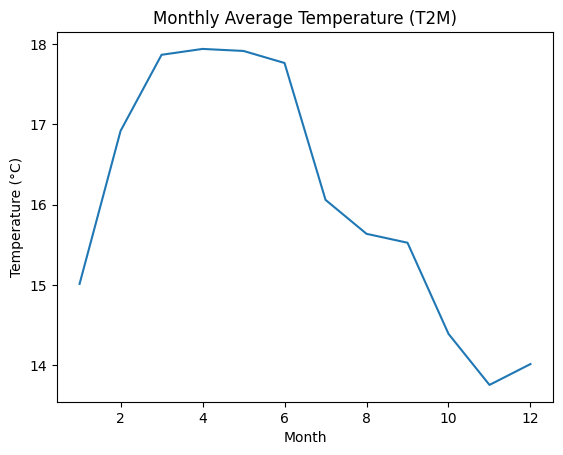

In [18]:
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [19]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(4), np.int32(11))

### Monthly Temperature Trend

The temperature shows seasonal variation across the year. The warmest period occurs in month 4, while the coolest occurs in month 11. There are no obvious anomalies.

In [20]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain

Month
1      138.37
2      352.81
3      667.34
4     1169.67
5     1104.80
6     1735.56
7     3270.52
8     3466.35
9     2106.66
10     567.23
11     226.80
12     121.52
Name: PRECTOTCORR, dtype: float64

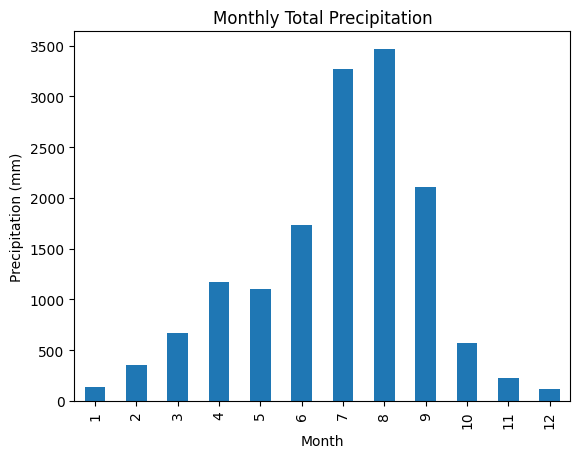

In [21]:
plt.figure()
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

In [22]:
monthly_rain.sort_values(ascending=False).head(3)

Month
8    3466.35
7    3270.52
9    2106.66
Name: PRECTOTCORR, dtype: float64

### Monthly Precipitation Analysis

The peak rainy months are July, August and September. The majority of precipitation occurs during specific months, indicating a distinct rainy season. 

In [23]:
numeric_df = df[[
    "T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]]

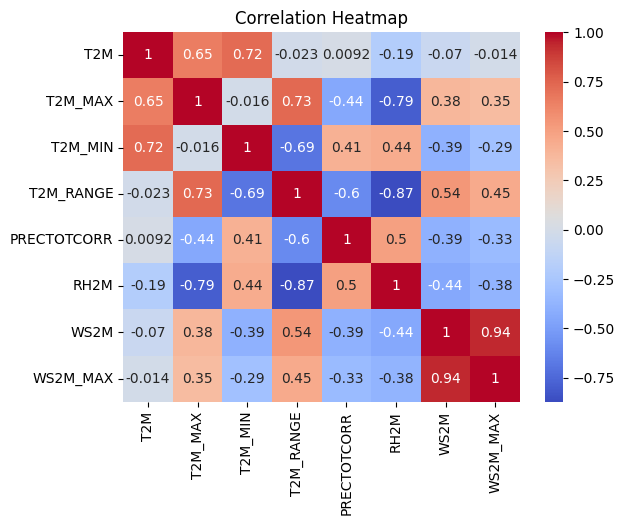

In [24]:
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

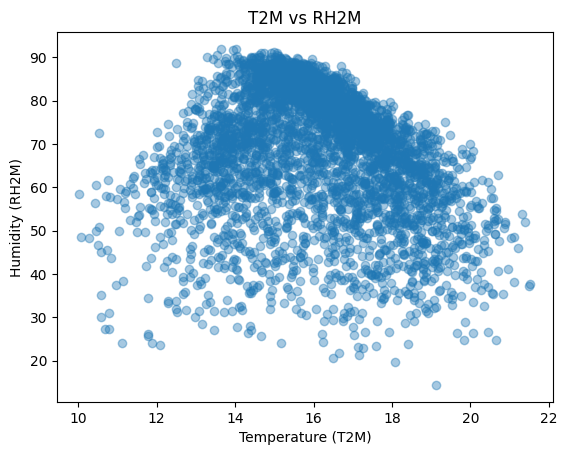

In [25]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

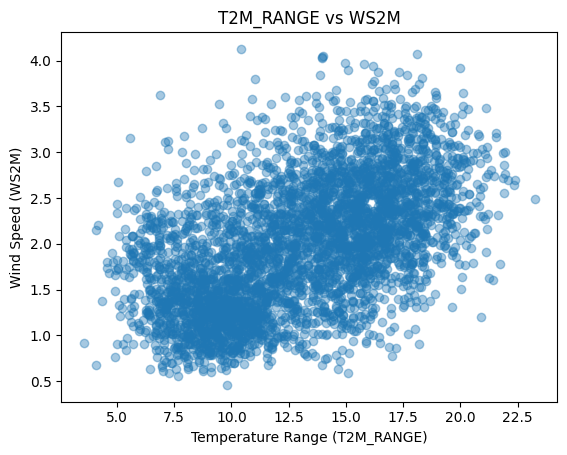

In [26]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.4)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.show()

In [27]:
corr = numeric_df.corr().abs()

top_3 = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(3)
)

top_3

WS2M       WS2M_MAX    0.940826
T2M_RANGE  RH2M        0.872156
T2M_MAX    RH2M        0.792422
dtype: float64

### Strongest Correlations

The three strongest correlations in the dataset are:

1. WS2M and WS2M_MAX (0.940826)
2. T2M_RANGE and RH2M (0.872156)
3. T2M_MAX and RH2M (0.792422)

Interpretation:
- Daily average wind speed and maximum wind speed are very strongly correlated, which is expected since they measure similar wind conditions.

- Temperature range (T2M_RANGE) and humidity (RH2M) are very strongly correlated.This indicates that days with larger temperature fluctuations tend to also have higher humidity levels.

- Maximum temperature (T2M_MAX) and humidity (RH2M) are also strongly correlated.This suggests that warmer days also have higher moisture levels in the air.


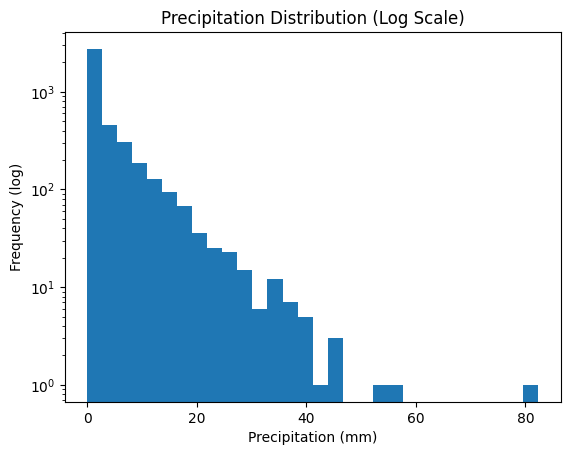

In [28]:
plt.figure()
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Precipitation Distribution (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log)")
plt.show()

### Precipitation Distribution

The distribution of daily precipitation is highly skewed, with most values clustered near zero and only a few extreme rainfall events.

This indicates that:
- Most days are dry or experience very low rainfall
- Heavy rainfall events occur occasionally

This pattern is typical of seasonal climates with distinct wet and dry periods.

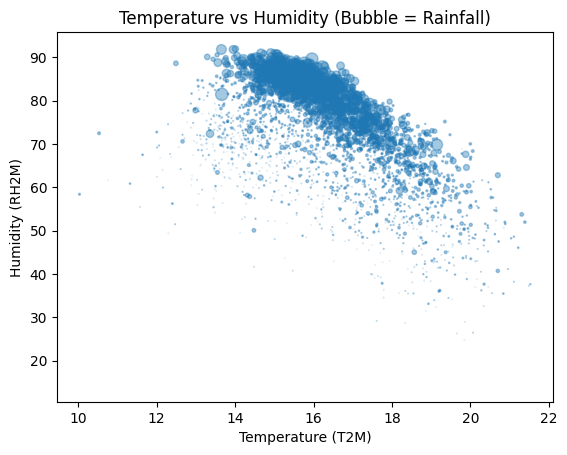

In [29]:
plt.figure()

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,
    alpha=0.4
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Analysis

The bubble chart shows the relationship between temperature (T2M) and humidity (RH2M), with rainfall represented by bubble size.

Observations:
- Higher rainfall values (larger bubbles) appear at higher humidity levels.
- Rainfall is not evenly distributed but concentrated in specific climate conditions.
